# Project 3 | Build and Visualize a Perceptron

## Project Description

**Objective**: Implement the complete Perceptron learning algorithm from scratch using NumPy.

Your implementation should:

- Initialize weights and bias.
- Train using the Perceptron Learning Rule.
- Iterate over a linearly separable binary classification dataset.
- Track the number of misclassifications per epoch.
- Plot the learned decision boundary (for a 2D dataset).
- Experiment with different learning rates and observe how training changes.

The purpose of this project is to see learning happen visually: the decision boundary moving as the model corrects its mistakes.

## My Solution

In [1]:
from pprint import pprint

import numpy as np
import pandas as pd

from matplotlib.figure import Figure
from IPython.display import display
import seaborn as sns

from sklearn.datasets import load_iris

In [2]:
dataset = load_iris(as_frame=True).frame
dataset = dataset[dataset['target'] < 2]
dataset = dataset.drop(['sepal width (cm)', 'petal width (cm)'], axis=1)
X = dataset.drop('target', axis=1)
y = dataset['target']

In [3]:
dataset

,sepal length (cm),petal length (cm),target
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
95,5.7,4.2,1
96,5.7,4.2,1
97,6.2,4.3,1
98,5.1,3.0,1


In [4]:
x1 = 'sepal length (cm)'
x2 = 'petal length (cm)'

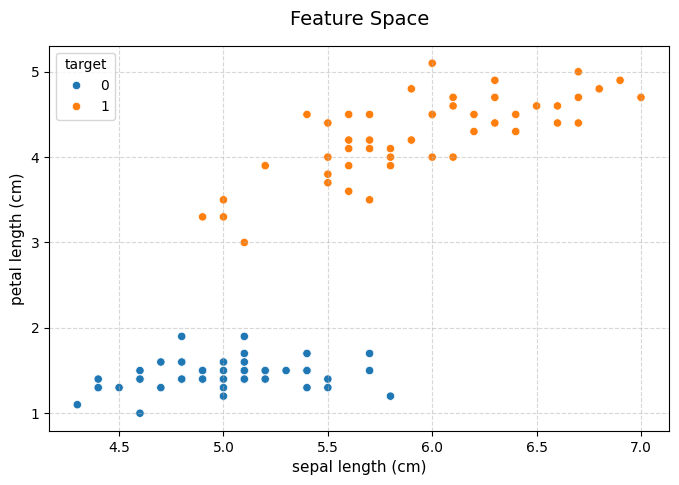

In [5]:
figureFeatureSpace = Figure(figsize=(8, 5))

axesFeatureSpace = figureFeatureSpace.add_subplot(1, 1, 1)

sns.scatterplot(data=dataset, x=x1, y=x2, hue=y, ax=axesFeatureSpace, color="#2b5c8f", alpha=1)

axesFeatureSpace.set_title("Feature Space", fontsize=14, pad=15)
axesFeatureSpace.set_xlabel(x1, fontsize=11)
axesFeatureSpace.set_ylabel(x2, fontsize=11)
axesFeatureSpace.grid(True, linestyle="--", alpha=0.5)

figureFeatureSpace.canvas.draw()
display(figureFeatureSpace)

The dataset is clearly linearly separable. I will train my perceptrons until I get a perfect decision boundary.

In [26]:
def generate_line_points(w, b, x1_range=(-1000, 1000), x2_range=(-1000, 1000), num_points=100):
    w1, w2 = w[0], w[1]

    # Case 1: Line is undefined (0*x1 + 0*x2 + b = 0)
    if w1 == 0 and w2 == 0:
        raise ValueError(
            "Weights w1 and w2 cannot both be zero. Undefined decision boundary."
        )

    # Case 2: Vertical Line (w2 = 0 -> x1 = -b / w1)
    if w2 == 0:
        x1_fixed = -b / w1
        x1_coords = np.full(num_points, x1_fixed)
        x2_coords = np.linspace(x2_range[0], x2_range[1], num_points)
        return x1_coords, x2_coords

    # Case 3: Standard Line (w2 != 0 -> x2 = (-w1*x1 - b) / w2)
    x1_coords = np.linspace(x1_range[0], x1_range[1], num_points)
    x2_coords = (-w1 * x1_coords - b) / w2

    return x1_coords, x2_coords

In [ ]:
class Perceptron:
    def __init__(self, eta):
        self.eta = eta
        self.w = np.array([0, 0])
        self.b = 0

    def activation(self, z):
        return np.where(z>=0, 1, 0)

    def predict(self, X):
        return self.activation(np.dot(X, self.w) + self.b)

    def fit(self, X, y, initial_w = np.array([0, 0]), initial_b = 0, verbose = True):
        self.w = initial_w
        self.b = initial_b
        
        perfectly_separated = False
        epoch_number = 1

        margin_x1 = (X[:, 0].max() - X[:, 0].min()) * 0.1
        margin_x2 = (X[:, 1].max() - X[:, 1].min()) * 0.1

        x1_min, x1_max = X[:, 0].min() - margin_x1, X[:, 0].max() + margin_x1
        x2_min, x2_max = X[:, 1].min() - margin_x2, X[:, 1].max() + margin_x2

        while not perfectly_separated:
            y_pred = self.predict(X)         
            error = y - y_pred
            number_of_misclassified_points = (error != 0).sum()
            perfectly_separated = number_of_misclassified_points == 0

            if verbose:
                print(f"Epoch Number: {epoch_number}\n")
                print(f"Before this Epoch:\nw = {self.w} b = {self.b}\nNumber of Misclassified Point(s): {number_of_misclassified_points}\n\n\n")
            
            if perfectly_separated:
                break

            # Not perfectly_separated yet
            pre_epoch_w = self.w
            pre_epoch_b = self.b
           
            
            self.w = self.w + self.eta * np.dot(X.T, error)
            self.b = self.b + self.eta * np.sum(error)
            # print(self.w)
            # print(self.b)
            # return

            y_pred = self.predict(X)
            error = y - y_pred
            number_of_misclassified_points = (error != 0).sum()
            perfectly_separated = number_of_misclassified_points == 0

            if verbose:

                figureFeatureSpace = Figure(figsize=(8, 5))
                
                axesFeatureSpace = figureFeatureSpace.add_subplot(1, 1, 1)

                sns.scatterplot(data=dataset, x=x1, y=x2, hue=y, ax=axesFeatureSpace, color="#2b5c8f", alpha=1)

                lines = [
                    (generate_line_points(pre_epoch_w, pre_epoch_b, x1_range=(x1_min, x1_max), x2_range=(x2_min, x2_max)), "Before Epoch", "yellow"),
                    (generate_line_points(pre_epoch_w * np.array([0, 1]) + self.w * np.array([1, 0]), pre_epoch_b, x1_range=(x1_min, x1_max), x2_range=(x2_min, x2_max)), "Updated w1", "royalblue"),
                    (generate_line_points(self.w, pre_epoch_b, x1_range=(x1_min, x1_max), x2_range=(x2_min, x2_max)), "Updated w2", "forestgreen"),
                    (generate_line_points(self.w, self.b, x1_range=(x1_min, x1_max), x2_range=(x2_min, x2_max)), "Update bias", "red")
                ]

                # Plot each line on the given Axes object
                for (x0, y0), label, color in lines:
                    sns.lineplot(x=x0, y=y0, label=label, color=color, ax=axesFeatureSpace)

                axesFeatureSpace.set_title("Feature Space", fontsize=14, pad=15)
                axesFeatureSpace.set_xlabel(x1, fontsize=11)
                axesFeatureSpace.set_ylabel(x2, fontsize=11)
                axesFeatureSpace.grid(True, linestyle="--", alpha=0.5)

                figureFeatureSpace.canvas.draw()
                display(figureFeatureSpace)

                print(f"\n\nAfter this Epoch: w = {self.w} b = {self.b}\nNumber of Misclassified Point(s): {number_of_misclassified_points}\n\n\n")
                print(("*" * 150 + '\n') * 3)
                print("\n\n\n")
                
            epoch_number += 1

In [38]:
perceptron1 = Perceptron(eta = 0.01)
perceptron1.fit(X=np.array(X), y=y, initial_w= np.array([0, 1]), initial_b = 2)

0    -1
1    -1
2    -1
3    -1
4    -1
     ..
95    0
96    0
97    0
98    0
99    0
Name: target, Length: 100, dtype: int64
